# Prueba Técnica - Voice of Customer (VoC), NLP & IA Generativa en Cobranzas

## 🎯 Objetivo de la prueba
Analizar la **Base Sintética Real de Conversaciones** (42,607 interacciones / 1,197 conversaciones) de WhatsApp mediante **IA Generativa y NLP Granular** para:
1. **Extracción Estructurada de Variables (Schema de IA)**: Clasificar *Disputa de saldo / Reclamo de cobro*, *Incoherencia de Cuota de Reestructuración*, *Abandono por Rebote de Canales*, *Falta de Liquidez*, *Pago Ya Realizado*, *Desempleo*, *Salud*, etc.
2. **Explicación del Flujo Conversacional en 4 Fases Operativas** (Autenticación, Objeción/Fricción, Ruptura/Rebote de Canales y Evaluación/Detracción).
3. **Prompts de Entorno de Producción y Esquema JSON Estricto** para evaluadores VoC.
4. **Evaluar la satisfacción del cliente (CSAT/Score 0-100 / Escala 1-7)** y profundizar en las 5 conversaciones de menor satisfacción.
5. **Propuesta Arquitectónica RAG** para estandarización de respuestas con guardrails de cumplimiento y 5 metodologías analíticas avanzadas.

## 1. Importación de Librerías y Configuración del Entorno

In [1]:
import sys
import io
if hasattr(sys.stdout, 'reconfigure'):
    sys.stdout.reconfigure(encoding='utf-8')

import re
import json
from pathlib import Path
from collections import Counter
from datetime import datetime
from dateutil import parser as date_parser

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 300
pd.set_option("display.max_colwidth", 160)
pd.set_option("display.max_columns", None)

print("[OK] Entorno y librerias cargadas correctamente.")

[OK] Entorno y librerias cargadas correctamente.


## 2. Ingesta de la Base Sintética Real (42,607 interacciones)

In [2]:
excel_path = Path("Base sintetica conversaciones.xlsx")
if not excel_path.exists():
    excel_path = Path("data/Base sintetica conversaciones.xlsx")
    
if not excel_path.exists():
    raise FileNotFoundError("No se encontro Base sintetica conversaciones.xlsx")

df_raw = pd.read_excel(excel_path)
print(f"[DATA] Base real cargada: {len(df_raw)} mensajes en {df_raw['uk_id_conversacion'].nunique()} conversaciones.")

role_map = {"USUARIO": "cliente", "AGENTE": "asesor", "BOT": "bot", "HSM": "plantilla_hsm"}
df_raw["speaker_role"] = df_raw["de"].map(lambda x: role_map.get(str(x).upper(), "otro"))

df_raw.head(8)

[DATA] Base real cargada: 42607 mensajes en 1197 conversaciones.


,uk_id_conversacion,total_interacciones,anio,mes,de,uk_id_mensaje,uk_id_conversacion1,mensaje,speaker_role
0,CONV_00000001,37,2010,Julio,USUARIO,MSG_00000001,CONV_00000001,HABLAR CON ASESOR,cliente
1,CONV_00000001,37,2010,Julio,BOT,MSG_00000002,CONV_00000001,AL CONTINUAR NOS AUTORIZAS A QUE TUS DATOS SEAN TRATADOS CONFORME A LA LEY 1581 DEL FECHA_00000213 DE PROTECCIÓN DE DATOS QUE SE ENCUENTRA EN EL SIGUIENTE E...,bot
2,CONV_00000001,37,2010,Julio,BOT,MSG_00000003,CONV_00000001,"ESTAMOS VALIDANDO TU INFORMACIÓN. EN UN MOMENTO, UNO DE NUESTROS ASESORES TE AYUDARÁ A ENCONTRAR LA MEJOR ALTERNATIVA PARA QUE ESTÉS AL DÍA CON TUS OBLIGACI...",bot
3,CONV_00000001,37,2010,Julio,BOT,MSG_00000004,CONV_00000001,"HOLA, MI NOMBRE ES PERSONA_00000134, SOY ASESOR DEL BANCO_000001. POR FAVOR INDÍCAME LA FECHA DE EXPEDICIÓN DE TÚ DOCUMENTO Y EL CORREO ELECTRÓNICO REGISTRADO.",bot
4,CONV_00000001,37,2010,Julio,USUARIO,MSG_00000005,CONV_00000001,FECHA_ANONIMIZADA,cliente
5,CONV_00000001,37,2010,Julio,USUARIO,MSG_00000006,CONV_00000001,DOCUMENTO_00000001 EMAIL_00000001,cliente
6,CONV_00000001,37,2010,Julio,AGENTE,MSG_00000007,CONV_00000001,¿CUÉNTAME EN QUÉ TE PUEDO AYUDAR?,asesor
7,CONV_00000001,37,2010,Julio,USUARIO,MSG_00000008,CONV_00000001,PODRÍAS ENVIARME EL VALOR A PAGAR DE MI CRÉDITO Y EL SALDO QUE TENGO GRACIAS,cliente


## 3. Pipeline de IA Generativa con Groq y GPT-OSS 20B - Clasificación Semántica Real

Este módulo reemplaza completamente las expresiones regulares y diccionarios heurísticos por llamadas reales a GPT-OSS 20B servidas por Groq, con salida JSON estructurada.

El LLM comprende el contexto semántico completo de cada conversación:

| Limitación del regex | Solución con LLM |
|---|---|
| `'ya pagué pero sigue en mora'` -> falso positivo `pago_ya_realizado` | LLM detecta contexto real -> `disputa_saldo_o_cobro` |
| `'ando en la olla'` -> sin clasificar | LLM entiende modismo -> `falta_liquidez` |
| Acuerdo sin fecha marcado como acuerdo | LLM aplica regla: intención + fecha = acuerdo |
| Sin detección de tono emocional | LLM clasifica: frustrado / colaborativo / evasivo |

In [3]:
import os, re, time, json as _json
from urllib import error as urlerror
from urllib import request as urlrequest
import numpy as np
from dotenv import load_dotenv
from groq import Groq
from google import genai
from google.genai import types

# Cargar API key desde .env
load_dotenv()
GROQ_API_KEY = os.getenv('GROQ_API_KEY', '')
assert GROQ_API_KEY and GROQ_API_KEY != 'PEGA_TU_API_KEY_AQUI', \
    'ERROR: Agrega GROQ_API_KEY a .env con tu clave de https://console.groq.com/keys'

MODEL_NAME = 'openai/gpt-oss-20b'
groq_client = Groq(api_key=GROQ_API_KEY)
print(f'[OK] Conectado a Groq: {MODEL_NAME}')

GOOGLE_API_KEY = os.getenv('GOOGLE_API_KEY', '')
assert GOOGLE_API_KEY and GOOGLE_API_KEY != 'PEGA_TU_API_KEY_AQUI', \
    'ERROR: Agrega GOOGLE_API_KEY a .env para habilitar el fallback de Gemini'
GEMINI_MODEL_NAMES = ('gemini-3.5-flash-lite', 'gemini-3.1-flash-lite', 'gemini-3.6-flash', 'gemini-3.5-flash')
GEMINI_MODEL_NAME = GEMINI_MODEL_NAMES[0]
gemini_client = genai.Client(
    api_key=GOOGLE_API_KEY,
    http_options=types.HttpOptions(timeout=45000, retry_options={'attempts': 1}),
)
print(f"[OK] Fallback Gemini configurado: {' -> '.join(GEMINI_MODEL_NAMES)}")

# Respaldo final mediante Ollama Cloud: inicia sesion y ejecuta ollama run gemma4:31b-cloud antes de ejecutar.
OLLAMA_URL = 'http://127.0.0.1:11434/api/chat'
OLLAMA_MODEL_NAME = 'gemma4:31b-cloud'
OLLAMA_TIMEOUT_S = 180
OLLAMA_AVAILABLE = True
print(f'[OK] Fallback local configurado: Ollama / {OLLAMA_MODEL_NAME}')

SYSTEM_PROMPT = '''Eres un analista experto en Voice of Customer (VoC) especializado
en operaciones de cobranza bancaria por WhatsApp en America Latina.

REGLAS CRITICAS:
1. motivos_no_pago SOLO de lo que el CLIENTE dijo explicitamente.
   NO inferas motivos de mensajes del ASESOR, BOT o HSM.
2. acuerdo_pago = 1 UNICAMENTE si el CLIENTE expresa intencion de pago Y
   menciona una fecha especifica (dia/mes o dia de la semana).
   Solo 'voy a pagar' sin fecha -> acuerdo_pago = 0.
3. Si cliente dice 'ya pague' o similar -> motivos incluye pago_ya_realizado
   y requiere_escalamiento = true. NO insistir en cobro.
4. Disputa o cliente no reconoce deuda -> requiere_escalamiento = true.
5. Sin motivo explicito del cliente -> motivos_no_pago = [desconexion_o_rebote].
6. Responde UNICAMENTE con JSON valido. Sin texto extra. Sin markdown.

TAXONOMIA DE MOTIVOS (usa solo estas categorias en la lista):
  desconexion_o_rebote | falta_liquidez | pago_ya_realizado
  priorizacion_otros_gastos | desempleo | salud
  disputa_saldo_o_cobro | consulta_o_tramite | emergencia_familiar

TAXONOMIA DE OFERTAS (usa solo estas):
  descuento | fraccionamiento | extension_plazo
  condonacion_intereses | refinanciacion | derivacion_reclamos

TAXONOMIA DE ARGUMENTOS (usa solo estos):
  evitar_reporte | evitar_gastos | beneficio_inmediato | empatia_y_apoyo
'''

OUTPUT_SCHEMA = {
    '$schema': 'http://json-schema.org/draft-07/schema',
    'title': 'AnalisisConversacionCobranza',
    'type': 'object',
    'required': ['motivos_no_pago', 'acuerdo_pago', 'requiere_escalamiento',
                 'resumen_conversacion', 'score_riesgo_cx'],
    'properties': {
        'motivos_no_pago': {
            'type': 'array', 'items': {'type': 'string'},
            'description': 'Motivos expresados EXPLICITAMENTE por el CLIENTE'
        },
        'submotivo': {'type': 'string', 'description': 'Descripcion con las palabras del cliente'},
        'ofertas_asesor': {'type': 'array', 'items': {'type': 'string'}},
        'argumentos_asesor': {'type': 'array', 'items': {'type': 'string'}},
        'acuerdo_pago': {
            'type': 'integer', 'enum': [0, 1],
            'description': '1 SOLO si cliente da intencion + fecha especifica'
        },
        'fecha_compromiso': {'type': ['string', 'null']},
        'tono_cliente': {
            'type': 'string',
            'enum': ['colaborativo', 'neutral', 'frustrado', 'indignado', 'evasivo']
        },
        'tono_asesor': {
            'type': 'string',
            'enum': ['empatico', 'neutral', 'presionador', 'ineficaz']
        },
        'requiere_escalamiento': {
            'type': 'boolean',
            'description': 'true si hay disputa, pago ya realizado o cobro erroneo'
        },
        'resumen_conversacion': {
            'type': 'string',
            'description': 'Resumen en 2-3 oraciones: contexto | objecion | resultado'
        },
        'score_riesgo_cx': {
            'type': 'integer', 'minimum': 0, 'maximum': 10,
            'description': '10=muy alto riesgo de mala experiencia, 0=sin riesgo'
        }
    }
}

print('[OK] System Prompt y JSON Schema configurados.')
print(f'     {len(OUTPUT_SCHEMA["properties"])} campos de salida estructurada.')

[OK] Conectado a Groq: openai/gpt-oss-20b
[OK] Fallback Gemini configurado: gemini-3.5-flash-lite -> gemini-3.1-flash-lite -> gemini-3.6-flash -> gemini-3.5-flash
[OK] Fallback local configurado: Ollama / gemma4:31b-cloud
[OK] System Prompt y JSON Schema configurados.
     11 campos de salida estructurada.


In [4]:
import threading

MAX_COMPLETION_TOKENS = 1500  # Margen para reasoning low y una respuesta JSON completa.
MAX_COMPLETION_TOKENS_BY_MODEL = {
    'openai/gpt-oss-20b': 1500,
    'qwen/qwen3.8-27b': 800,  # Limite OTPM de Qwen: 1,000; deja margen para su respuesta JSON.
}
MIN_REQUEST_INTERVAL_S = 35  # Espacio entre solicitudes del mismo modelo para respetar su TPM.
# el reasoning consume todo el presupuesto y el contenido llega vacio (finish_reason='length')

class GroqRateLimitedClient:
    '''Controla la cuota y normaliza JSON no estricto de GPT-OSS en Groq.'''
    def __init__(self, client):
        self._client = client
        self._cooldown_lock = threading.Lock()
        self._cooldown_until_by_model = {}
        self._next_request_at_by_model = {}

    @property
    def chat(self):
        return self

    @property
    def completions(self):
        return self

    def create(self, **kwargs):
        model_name = str(kwargs.get('model', ''))
        kwargs.setdefault('max_completion_tokens', MAX_COMPLETION_TOKENS_BY_MODEL.get(model_name, MAX_COMPLETION_TOKENS))
        if 'gpt-oss' in str(kwargs.get('model', '')):
            kwargs.setdefault('reasoning_effort', 'low')
        with self._cooldown_lock:
            now = time.monotonic()
            scheduled_at = max(now, self._cooldown_until_by_model.get(model_name, 0.0), self._next_request_at_by_model.get(model_name, 0.0))
            self._next_request_at_by_model[model_name] = scheduled_at + MIN_REQUEST_INTERVAL_S
            wait = scheduled_at - now
        if wait > 0:
            time.sleep(wait)
        try:
            response = self._client.chat.completions.create(**kwargs)
        except Exception as error:
            retry_after = re.search(r'try again in (?:(\d+)m)?([\d.]+)s', str(error), flags=re.IGNORECASE)
            if retry_after:
                with self._cooldown_lock:
                    retry_seconds = int(retry_after.group(1) or 0) * 60 + float(retry_after.group(2)) + 1
                    self._cooldown_until_by_model[model_name] = max(self._cooldown_until_by_model.get(model_name, 0.0), time.monotonic() + retry_seconds)
            raise

        choice = response.choices[0]
        content = (choice.message.content or '').strip()
        content = re.sub(r'<think>.*?</think>', '', content, flags=re.DOTALL).strip()
        content = re.sub(r'^```(?:json)?\s*|\s*```$', '', content).strip()
        match = re.search(r'\{.*\}\s*$', content, flags=re.DOTALL)
        if not match:
            raise ValueError(
                f'Respuesta vacia o sin JSON valido del modelo '
                f'(finish_reason={choice.finish_reason}, content_len={len(content)}).'
            )
        response.choices[0].message.content = match.group(0)
        return response


groq_client = GroqRateLimitedClient(groq_client)
print('[OK] Modo JSON forzado (json_object), reasoning_effort=low y maximo de 1500 tokens activados.')

[OK] Modo JSON forzado (json_object), reasoning_effort=low y maximo de 1500 tokens activados.


## 4. Ejecución del Pipeline LLM Concurrente (Groq analiza cada conversación)

> **Configuración de `SAMPLE_N`**:
> - `SAMPLE_N = 10` -> prueba rápida
> - `SAMPLE_N = 50` -> validación representativa
> - `SAMPLE_N = None` -> todas las 1,197 conversaciones
>
> El pipeline usa solicitudes concurrentes y guarda un **checkpoint CSV cada 100 conversaciones** para no perder avance.

In [5]:
import ast
import os
import random
from concurrent.futures import ThreadPoolExecutor, as_completed

# ─── PARÁMETROS ───────────────────────────────────────────────────────────────
SAMPLE_N = 600      # None = todas las conversaciones | int = solo N para prueba
MAX_WORKERS = 1    # La cuota de 8,000 TPM permite una conversacion grande por ventana.
MAX_RETRIES = 5    # Reintentos para errores transitorios del servicio
FALLBACK_MODEL = 'qwen/qwen3.8-27b'
MODEL_FALLBACK_WAIT_S = 5 * 60  # Ante cuota diaria larga, usar otro modelo en lugar de bloquear.
RESUMEN_ERROR_LLM = 'No se pudo analizar esta conversacion.'
ACTIVE_MODEL = MODEL_NAME  # Cambia a Qwen para el resto del lote si GPT-OSS agota su cuota diaria.
EXHAUSTED_GROQ_MODELS = set()
EXHAUSTED_GEMINI_MODELS = set()
USE_GEMINI_FALLBACK = False

# ─── FUNCIÓN DE LLAMADA AL LLM ────────────────────────────────────────────────
MAX_TRANSCRIPT_CHARS = 9000
KEY_CONTEXT_TERMS = ('pago', 'pague', 'cuota', 'deuda', 'saldo', 'mora', 'reclamo', 'error', 'extracto', 'acuerdo', 'oferta', 'descuento', 'cuotas', 'plazo', 'escalamiento')

def compactar_transcript(lines, max_chars=MAX_TRANSCRIPT_CHARS):
    '''Preserva evidencia conversacional relevante sin enviar transcripciones ilimitadas al LLM.'''
    if len('\n'.join(lines)) <= max_chars:
        return '\n'.join(lines)

    selected = set(range(min(6, len(lines)))) | set(range(max(0, len(lines) - 6), len(lines)))
    for index, line in enumerate(lines):
        normalized = line.lower()
        if normalized.startswith('[cliente]') or any(term in normalized for term in KEY_CONTEXT_TERMS):
            selected.add(index)

    compacted, previous_index = [], None
    for index in sorted(selected):
        if previous_index is not None and index > previous_index + 1:
            compacted.append(f'[... {index - previous_index - 1} turnos omitidos ...]')
        compacted.append(lines[index][:800])
        previous_index = index

    result = '\n'.join(compacted)
    if len(result) <= max_chars:
        return result
    marker = '\n[... transcript compactado por limite de contexto ...]'
    return result[:max_chars - len(marker)] + marker

def analizar_conv_gemini(conv_id, user_prompt, max_retries=1):
    '''Prueba cada Gemini una vez y cambia enseguida ante saturacion o salida invalida.'''
    global GEMINI_MODEL_NAME
    modelos = (GEMINI_MODEL_NAME,) + tuple(
        modelo for modelo in GEMINI_MODEL_NAMES if modelo != GEMINI_MODEL_NAME
    )
    ultimo_error = None

    for modelo in modelos:
        if modelo in EXHAUSTED_GEMINI_MODELS:
            continue
        for attempt in range(max_retries):
            try:
                response = gemini_client.models.generate_content(
                    model=modelo,
                    contents=[SYSTEM_PROMPT, user_prompt],
                    config=types.GenerateContentConfig(
                        temperature=0.1,
                        response_mime_type='application/json',
                        max_output_tokens=800,
                    ),
                )
                result = _json.loads(response.text.strip())
                GEMINI_MODEL_NAME = modelo
                result['_modelo_llm'] = modelo
                return result
            except Exception as error:
                ultimo_error = error
                error_text = str(error)
                cuota_agotada = '429' in error_text and 'RESOURCE_EXHAUSTED' in error_text
                if cuota_agotada:
                    EXHAUSTED_GEMINI_MODELS.add(modelo)
                    print(f'  [WARN] {conv_id} cuota de {modelo} agotada; probando otro modelo Gemini.')
                    break
                if attempt == max_retries - 1:
                    print(f'  [WARN] {conv_id} {modelo} no esta disponible; probando otro modelo Gemini.')
                    break
                wait = 2 ** attempt + random.uniform(0, 1)
                print(f'  [WARN] {conv_id} {modelo} intento {attempt + 1} fallido: {error}. Reintentando en {wait:.1f}s...')
                time.sleep(wait)

    raise ultimo_error or RuntimeError('No hay modelos Gemini disponibles para analizar la conversacion.')

def analizar_conv_ollama(conv_id, user_prompt):
    '''Analiza con Ollama Cloud cuando los proveedores externos no estan disponibles.'''
    global OLLAMA_AVAILABLE
    if not OLLAMA_AVAILABLE:
        raise RuntimeError('El fallback local de Ollama no esta disponible en esta ejecucion.')

    payload = _json.dumps({
        'model': OLLAMA_MODEL_NAME,
        'messages': [
            {'role': 'system', 'content': SYSTEM_PROMPT},
            {'role': 'user', 'content': user_prompt},
        ],
        'format': 'json',
        'stream': False,
        'options': {'temperature': 0.1, 'num_predict': 800},
    }).encode('utf-8')
    request = urlrequest.Request(
        OLLAMA_URL, data=payload, headers={'Content-Type': 'application/json'}, method='POST'
    )
    try:
        with urlrequest.urlopen(request, timeout=OLLAMA_TIMEOUT_S) as response:
            body = _json.loads(response.read().decode('utf-8'))
        result = _json.loads(body['message']['content'].strip())
        result['_modelo_llm'] = f'ollama/{OLLAMA_MODEL_NAME}'
        return result
    except (urlerror.URLError, TimeoutError, OSError, KeyError, TypeError, ValueError) as error:
        OLLAMA_AVAILABLE = False
        raise RuntimeError(
            f'Ollama no responde en {OLLAMA_URL}. Abre Ollama, inicia sesion y ejecuta ollama run {OLLAMA_MODEL_NAME}.'
        ) from error

def analizar_fallback_local(conv_id, user_prompt):
    try:
        print(f'  [WARN] {conv_id} proveedores externos no disponibles; probando Ollama Cloud / {OLLAMA_MODEL_NAME}.')
        return analizar_conv_ollama(conv_id, user_prompt)
    except RuntimeError as ollama_error:
        print(f'  [ERROR] {conv_id} Ollama no se pudo procesar: {ollama_error}')
        return None

def analizar_conv_llm(conv_id, transcript_lines, max_retries=MAX_RETRIES):
    '''Envia un transcript a Groq y retorna el JSON parseado.'''
    global ACTIVE_MODEL, USE_GEMINI_FALLBACK
    transcript_text = compactar_transcript(transcript_lines)
    user_prompt = (
        f'Analiza la siguiente conversacion de WhatsApp de cobranza bancaria.\n'
        f'Conversation ID: {conv_id}\n\n'
        f'--- INICIO DE CONVERSACION ---\n{transcript_text}\n--- FIN ---\n\n'
        f'Responde con un JSON siguiendo este schema:\n'
        f'{_json.dumps(OUTPUT_SCHEMA, ensure_ascii=False, indent=2)}\n\n'
        f'IMPORTANTE: Responde SOLO con el JSON, sin texto adicional ni markdown.'
    )
    if USE_GEMINI_FALLBACK:
        try:
            return analizar_conv_gemini(conv_id, user_prompt)
        except Exception as gemini_error:
            print(f'  [ERROR] {conv_id} Gemini no se pudo procesar: {gemini_error}')
            ollama_result = analizar_fallback_local(conv_id, user_prompt)
            if ollama_result is not None:
                return ollama_result
            return {
                'motivos_no_pago': ['desconexion_o_rebote'], 'submotivo': 'Error LLM',
                'ofertas_asesor': [], 'argumentos_asesor': [],
                'acuerdo_pago': 0, 'fecha_compromiso': None,
                'tono_cliente': 'neutral', 'tono_asesor': 'neutral',
                'requiere_escalamiento': False,
                'resumen_conversacion': RESUMEN_ERROR_LLM,
                'score_riesgo_cx': 5, '_modelo_llm': GEMINI_MODEL_NAME,
                '_analysis_failed': True,
            }
    transient_errors = ('429', '500', '502', '503', '504', 'UNAVAILABLE', 'RESOURCE_EXHAUSTED', 'json_validate_failed')
    groq_models_to_try = [ACTIVE_MODEL, FALLBACK_MODEL if ACTIVE_MODEL == MODEL_NAME else MODEL_NAME]
    model_index = 0
    use_json_mode = True

    for attempt in range(max_retries):
        try:
            request_args = {
                'model': groq_models_to_try[model_index],
                'messages': [
                    {'role': 'system', 'content': SYSTEM_PROMPT},
                    {'role': 'user', 'content': user_prompt},
                ],
                'temperature': 0.1,
            }
            if use_json_mode:
                request_args['response_format'] = {'type': 'json_object'}
            response = groq_client.chat.completions.create(**request_args)
            result = _json.loads(response.choices[0].message.content.strip())
            result['_modelo_llm'] = groq_models_to_try[model_index]
            return result
        except Exception as e:
            error_text = str(e)
            if 'json_validate_failed' in error_text:
                use_json_mode = False
            retry_after = re.search(r'try again in (?:(\d+)m)?([\d.]+)s', error_text, flags=re.IGNORECASE)
            retry_seconds = int(retry_after.group(1) or 0) * 60 + float(retry_after.group(2)) if retry_after else 0
            if 'tokens per day' in error_text and retry_seconds >= MODEL_FALLBACK_WAIT_S:
                EXHAUSTED_GROQ_MODELS.add(groq_models_to_try[model_index])
                if {MODEL_NAME, FALLBACK_MODEL}.issubset(EXHAUSTED_GROQ_MODELS):
                    USE_GEMINI_FALLBACK = True
                    print(f'  [WARN] {conv_id} cuotas diarias de Groq agotadas; cambiando el resto del lote a {GEMINI_MODEL_NAME}.')
                    try:
                        return analizar_conv_gemini(conv_id, user_prompt)
                    except Exception as gemini_error:
                        print(f'  [ERROR] {conv_id} Gemini no se pudo procesar: {gemini_error}')
                        ollama_result = analizar_fallback_local(conv_id, user_prompt)
                        if ollama_result is not None:
                            return ollama_result
                        break
            if 'tokens per day' in error_text and retry_seconds >= MODEL_FALLBACK_WAIT_S and model_index == 0:
                previous_model = groq_models_to_try[model_index]
                model_index += 1
                ACTIVE_MODEL = groq_models_to_try[model_index]
                use_json_mode = True
                print(f'  [WARN] {conv_id} cuota diaria de {previous_model} agotada; cambiando el resto del lote a {ACTIVE_MODEL}.')
                continue
            is_transient = any(code in error_text for code in transient_errors)
            if not is_transient or attempt == max_retries - 1:
                print(f'  [ERROR] {conv_id} no se pudo procesar: {e}')
                break
            wait = retry_seconds + 1 if retry_after else min(60, (2 ** attempt) + random.uniform(0, 1))
            print(f'  [WARN] {conv_id} intento {attempt + 1} fallido: {e}. Reintentando en {wait:.1f}s...')
            time.sleep(wait)

    return {
        'motivos_no_pago': ['desconexion_o_rebote'], 'submotivo': 'Error LLM',
        'ofertas_asesor': [], 'argumentos_asesor': [],
        'acuerdo_pago': 0, 'fecha_compromiso': None,
        'tono_cliente': 'neutral', 'tono_asesor': 'neutral',
        'requiere_escalamiento': False,
        'resumen_conversacion': RESUMEN_ERROR_LLM,
        'score_riesgo_cx': 5, '_modelo_llm': groq_models_to_try[model_index],
        '_analysis_failed': True,
    }

# ─── PREPARAR DATOS ───────────────────────────────────────────────────────────
role_map = {'USUARIO': 'CLIENTE', 'AGENTE': 'ASESOR', 'BOT': 'BOT', 'HSM': 'HSM'}
df_raw['rol'] = df_raw['de'].map(lambda x: role_map.get(str(x).upper(), str(x).upper()))
df_raw['prev_msg'] = df_raw.groupby('uk_id_conversacion')['mensaje'].shift(1).fillna('')
df_raw['csat_encuesta'] = np.nan
for idx, row in df_raw.iterrows():
    if row['rol'] == 'CLIENTE':
        text = str(row['mensaje']).strip()
        previous = str(row['prev_msg']).lower()
        if text.isdigit():
            value = int(text)
            if 'escala del 1 al 7' in previous and 1 <= value <= 7:
                df_raw.at[idx, 'csat_encuesta'] = value
            elif ('escala del 0 al 10' in previous or 'escala de 0 al 10' in previous) and 0 <= value <= 10:
                df_raw.at[idx, 'csat_encuesta'] = int(round((value / 10.0) * 7.0))

grouped = df_raw.groupby('uk_id_conversacion')
all_ids = list(grouped.groups.keys())
if SAMPLE_N:
    all_ids = all_ids[:SAMPLE_N]
    print(f'[INFO] Modo muestra: {SAMPLE_N} conversaciones')

# ─── PREPARAR SOLICITUDES ─────────────────────────────────────────────────────
work_items = []
for position, conv_id in enumerate(all_ids, 1):
    group = grouped.get_group(conv_id)
    lines = [
        f"[{record['rol']}]: {str(record['mensaje']).strip()}"
        for _, record in group.iterrows()
        if str(record['mensaje']).strip().lower() not in ['nan', '']
    ]
    csat_vals = group['csat_encuesta'].dropna()
    work_items.append({
        'position': position,
        'conversation_id': conv_id,
        'total_interacciones': group['total_interacciones'].iloc[0] if 'total_interacciones' in group.columns else len(group),
        'total_mensajes': len(group),
        'csat_declarado': float(csat_vals.iloc[0]) if len(csat_vals) > 0 else np.nan,
        'lines': lines,
    })

output_dir = Path('outputs')
output_dir.mkdir(parents=True, exist_ok=True)
progress_path = output_dir / 'conversaciones_enriquecidas_parcial.csv'
progress_status_path = output_dir / 'progreso_llm.json'
position_by_id = {conv_id: position for position, conv_id in enumerate(all_ids, 1)}

def parse_list(value):
    if isinstance(value, list):
        return value
    if pd.isna(value) or not str(value).strip():
        return []
    try:
        return ast.literal_eval(str(value))
    except (SyntaxError, ValueError):
        return []

def calc_score_satisfaccion(row):
    '''Score 0-100. CSAT declarado tiene prioridad; si no, usa score_riesgo_cx del LLM.'''
    if pd.notna(row.get('csat_declarado')):
        return int(np.clip(round(((int(row['csat_declarado']) - 1) / 6.0) * 100), 0, 100))
    base = int(np.clip((10 - row.get('score_riesgo_cx', 5)) * 10, 0, 100))
    if row.get('acuerdo_pago', 0) == 1:
        base = min(base + 10, 100)
    if row.get('requiere_escalamiento', False):
        base = max(base - 20, 0)
    return base

results_by_position = {}
failed_saved_results = 0
existing_results_path = progress_path if progress_path.exists() else output_dir / 'conversaciones_enriquecidas.csv'
if existing_results_path.exists():
    saved_results = pd.read_csv(existing_results_path)
    for _, saved in saved_results.drop_duplicates('conversation_id', keep='last').iterrows():
        if saved.get('resumen_conversacion') == RESUMEN_ERROR_LLM:
            failed_saved_results += 1
            continue
        position = position_by_id.get(saved['conversation_id'])
        if position is not None:
            result = saved.to_dict()
            for field in ('motivos_no_pago', 'ofertas_asesor', 'argumentos_asesor'):
                result[field] = parse_list(result.get(field))
            results_by_position[position] = result
    print(f'[INFO] Reanudando desde progreso: {len(results_by_position)} conversaciones ya procesadas.')
    if failed_saved_results:
        print(f'[INFO] Se reintentaran {failed_saved_results} conversaciones con errores LLM previos.')

work_items = [item for item in work_items if item['position'] not in results_by_position]
total = len(work_items)

def guardar_progreso():
    partial = pd.DataFrame([results_by_position[position] for position in sorted(results_by_position)])
    if len(partial):
        partial['score_satisfaccion'] = partial.apply(calc_score_satisfaccion, axis=1)
    tmp_path = progress_path.with_suffix('.tmp')
    partial.to_csv(tmp_path, index=False)
    os.replace(tmp_path, progress_path)
    status = {'procesadas': len(results_by_position), 'total': len(all_ids), 'actualizado_en': datetime.now().isoformat(timespec='seconds')}
    tmp_status_path = progress_status_path.with_suffix('.tmp')
    with open(tmp_status_path, 'w', encoding='utf-8') as status_file:
        _json.dump(status, status_file)
    os.replace(tmp_status_path, progress_status_path)

if failed_saved_results:
    guardar_progreso()

# ─── LOOP PRINCIPAL CONCURRENTE ───────────────────────────────────────────────
print(f'Iniciando analisis LLM de {total} conversaciones pendientes con Groq / {MODEL_NAME} usando {MAX_WORKERS} solicitudes simultaneas...')

with ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
    futures = {
        executor.submit(analizar_conv_llm, item['conversation_id'], item['lines']): item
        for item in work_items
    }
    for completed, future in enumerate(as_completed(futures), 1):
        item = futures[future]
        llm = future.result()
        if llm.get('_analysis_failed', False):
            print(f'  [WARN] {item["conversation_id"]} queda pendiente para un reintento posterior.')
            continue
        results_by_position[item['position']] = {
            'conversation_id': item['conversation_id'],
            'total_interacciones': item['total_interacciones'],
            'total_mensajes': item['total_mensajes'],
            'csat_declarado': item['csat_declarado'],
            'motivos_no_pago': llm.get('motivos_no_pago', []),
            'submotivo': llm.get('submotivo', ''),
            'ofertas_asesor': llm.get('ofertas_asesor', []),
            'argumentos_asesor': llm.get('argumentos_asesor', []),
            'acuerdo_pago': int(llm.get('acuerdo_pago', 0)),
            'fecha_compromiso': llm.get('fecha_compromiso'),
            'tono_cliente': llm.get('tono_cliente', 'neutral'),
            'tono_asesor': llm.get('tono_asesor', 'neutral'),
            'requiere_escalamiento': bool(llm.get('requiere_escalamiento', False)),
            'resumen_conversacion': llm.get('resumen_conversacion', ''),
            'score_riesgo_cx': int(llm.get('score_riesgo_cx', 5)),
            'modelo_llm': llm.get('_modelo_llm', MODEL_NAME),
            'transcript': '\n'.join(item['lines']),
        }
        guardar_progreso()
        if completed % 10 == 0 or completed == 1 or completed == total:
            print(f'  [{completed}/{total}] conversaciones completadas...')
        if completed % 100 == 0:
            pd.DataFrame([results_by_position[position] for position in sorted(results_by_position)]).to_csv(output_dir / f'checkpoint_{completed}.csv', index=False)
            print(f'  [CHECKPOINT] Guardado en outputs/checkpoint_{completed}.csv')

if not results_by_position:
    raise RuntimeError('No se obtuvo ningun analisis LLM. Reintenta cuando haya cuota disponible.')

results = [results_by_position[position] for position in sorted(results_by_position)]
conv = pd.DataFrame(results)

conv['score_satisfaccion'] = conv.apply(calc_score_satisfaccion, axis=1)
print(f'\n[OK] Pipeline LLM completado: {len(conv)} conversaciones procesadas')
print(f'     Acuerdos detectados:      {conv["acuerdo_pago"].sum()} ({conv["acuerdo_pago"].mean() * 100:.1f}%)')
print(f'     Requieren escalamiento:   {conv["requiere_escalamiento"].sum()}')
print(f'     Score CX promedio:        {conv["score_satisfaccion"].mean():.1f}/100')
print() 
print('=== DISTRIBUCION DE TONOS DEL CLIENTE (CLASIFICACION LLM) ===')
print(conv['tono_cliente'].value_counts().to_string())
conv.head(3)
print('=== DISTRIBUCION DE TONOS DEL ASESOR (CLASIFICACION LLM) ===')
print(conv['tono_asesor'].value_counts().to_string())
print('=== DISTRIBUCION DE MOTIVOS DE NO PAGO (CLASIFICACION LLM) ===')
print(conv['motivos_no_pago'].explode().value_counts().to_string())

[INFO] Modo muestra: 600 conversaciones
[INFO] Reanudando desde progreso: 544 conversaciones ya procesadas.
Iniciando analisis LLM de 56 conversaciones pendientes con Groq / openai/gpt-oss-20b usando 1 solicitudes simultaneas...


Direct use of automatic function calling (AFC) in Models.generate_content is not recommended. Instead, we recommend to use AFC in Chat.send_message. Similarly, direct use of AFC in Models.generate_content_stream is not recommended. Instead, we recommend to use AFC in Chat.send_message_stream.


  [WARN] CONV_00000541 cuota diaria de openai/gpt-oss-20b agotada; cambiando el resto del lote a qwen/qwen3.8-27b.
  [WARN] CONV_00000541 cuotas diarias de Groq agotadas; cambiando el resto del lote a gemini-3.5-flash-lite.
  [WARN] CONV_00000541 cuota de gemini-3.5-flash-lite agotada; probando otro modelo Gemini.
  [1/56] conversaciones completadas...
  [WARN] CONV_00000544 gemini-3.1-flash-lite no esta disponible; probando otro modelo Gemini.
  [WARN] CONV_00000544 cuota de gemini-3.6-flash agotada; probando otro modelo Gemini.
  [WARN] CONV_00000544 gemini-3.5-flash no esta disponible; probando otro modelo Gemini.
  [ERROR] CONV_00000544 Gemini no se pudo procesar: The read operation timed out
  [WARN] CONV_00000544 proveedores externos no disponibles; probando Ollama Cloud / gemma4:31b-cloud.
  [10/56] conversaciones completadas...
  [20/56] conversaciones completadas...
  [WARN] CONV_00000562 cuota de gemini-3.1-flash-lite agotada; probando otro modelo Gemini.
  [WARN] CONV_000005

## 5. Análisis Exploratorio de Datos (EDA) sobre la Base Real Granular

Respuesta a las **Preguntas de Negocio A, B y C**.

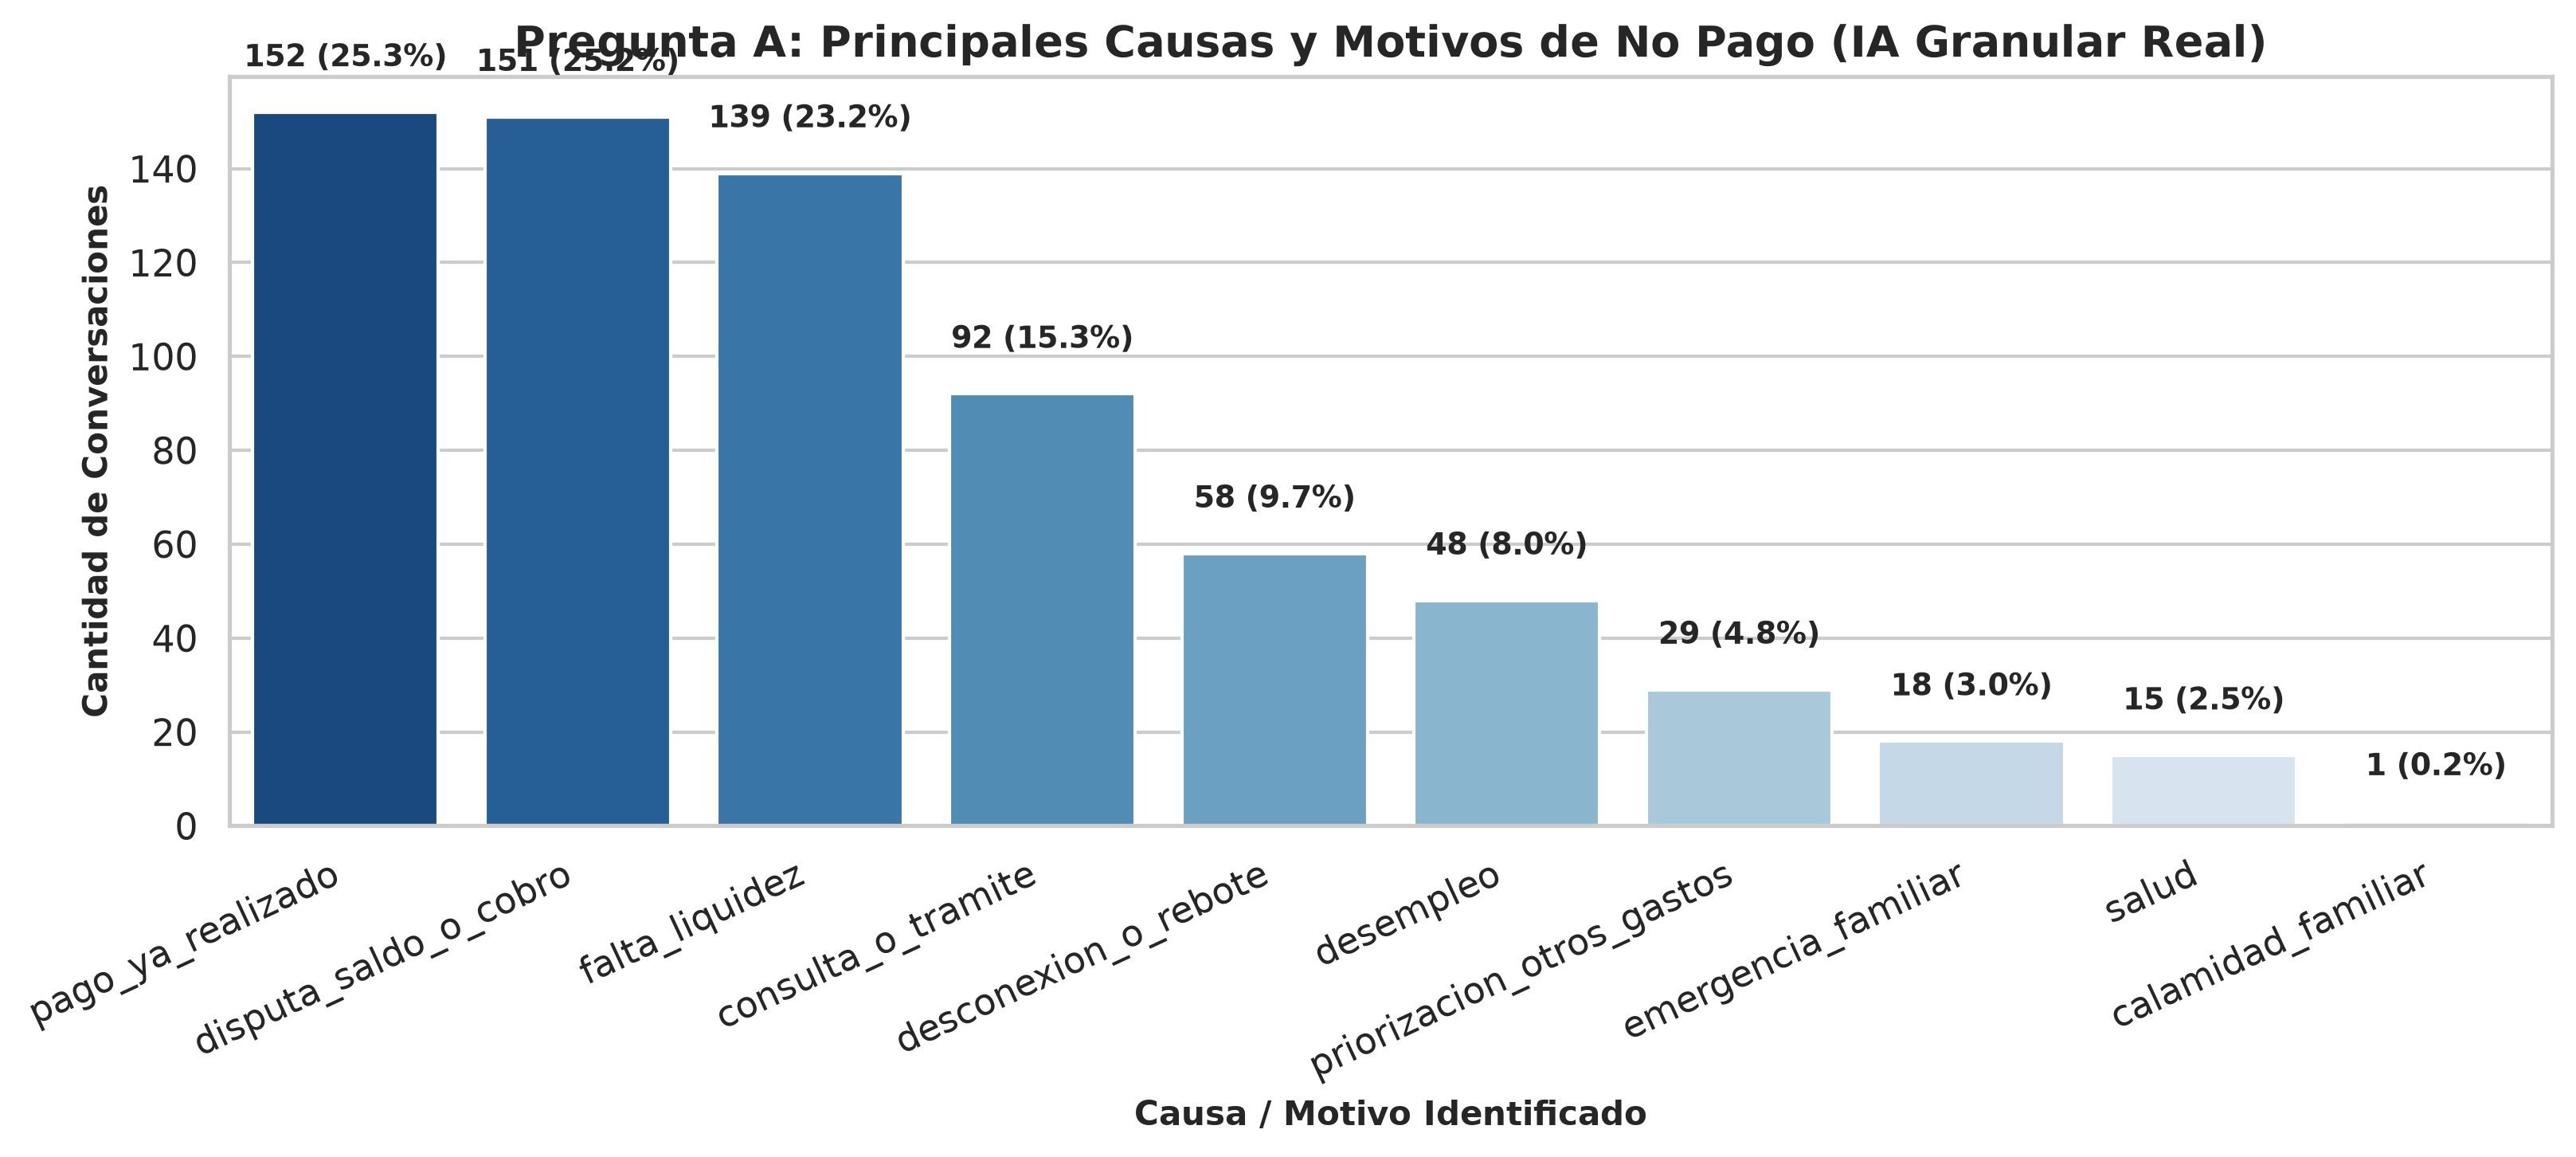

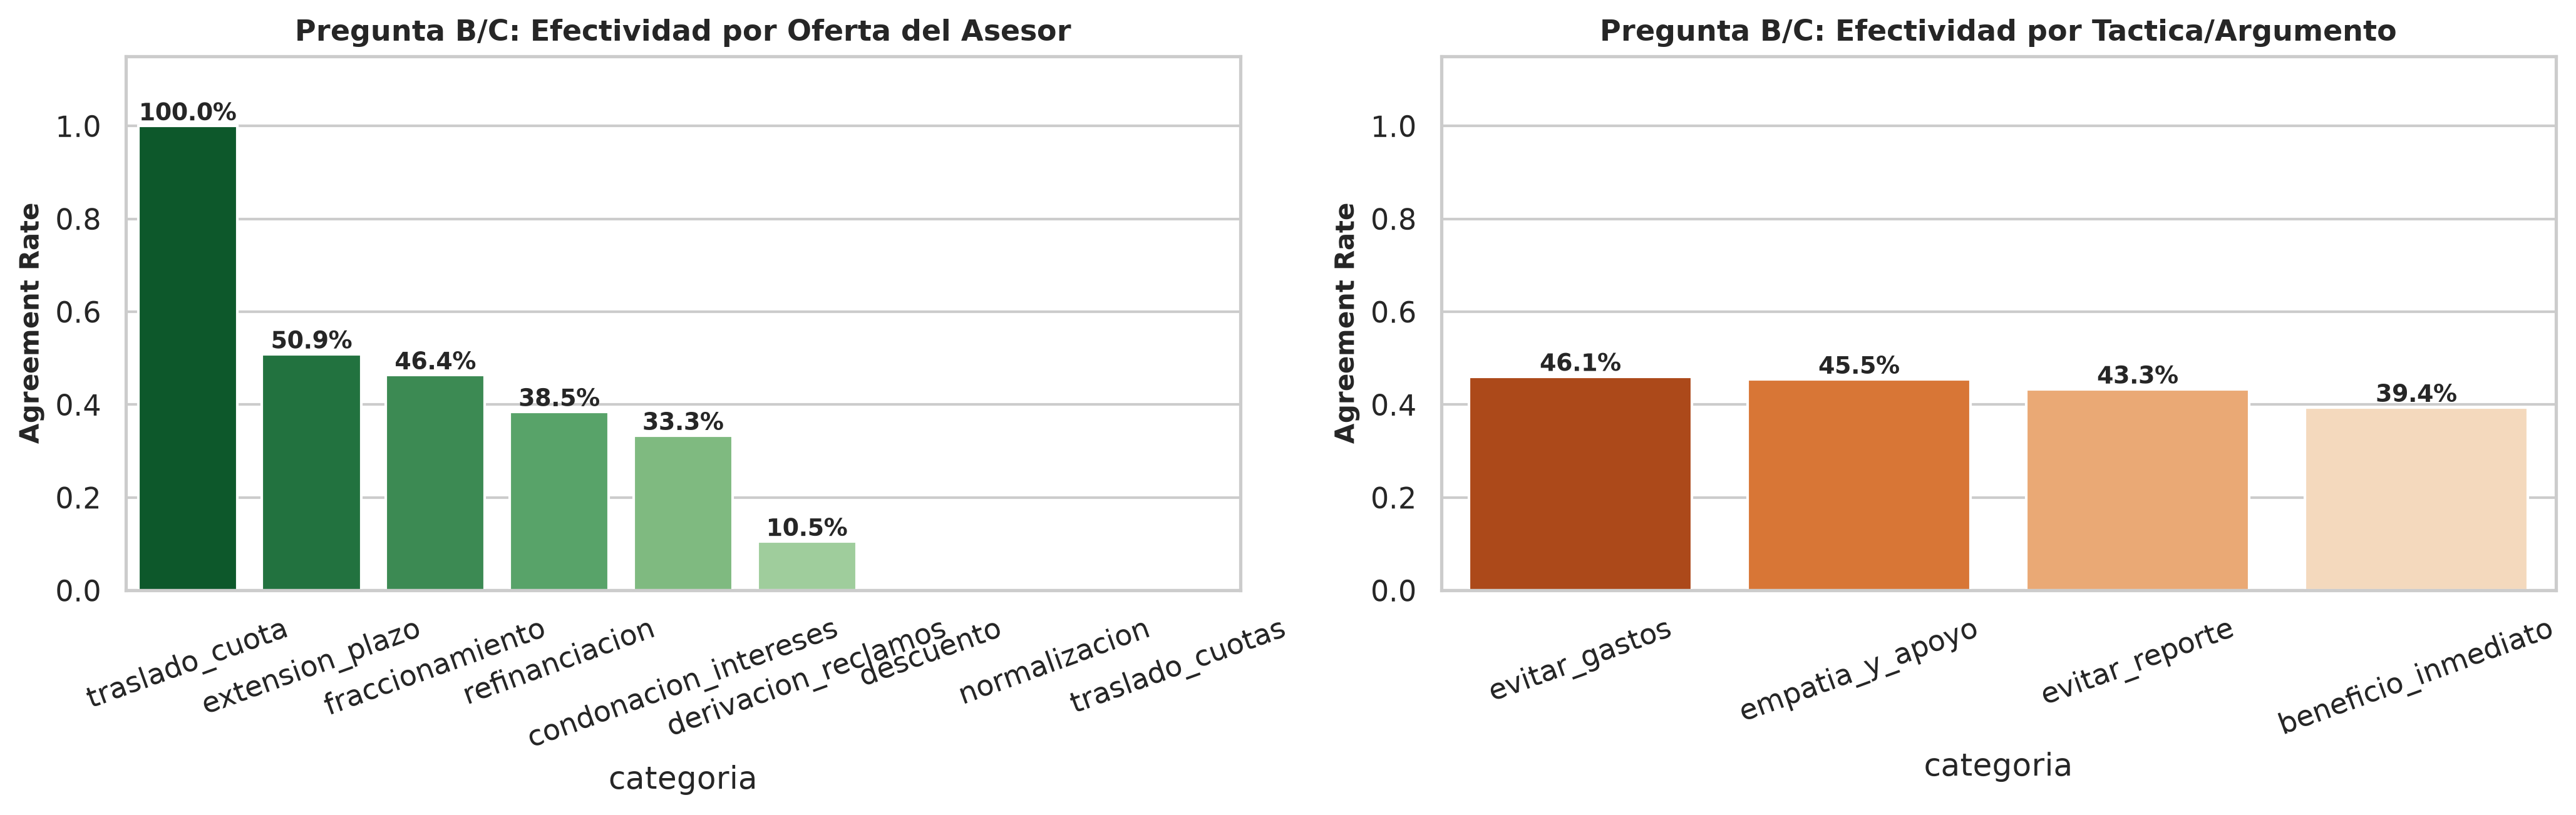

In [6]:
# Pregunta A: Principales Causas y Motivos de No Pago
motivos_counter = Counter()
for items in conv["motivos_no_pago"]:
    motivos_counter.update(items)

motivos_df = pd.DataFrame(motivos_counter.items(), columns=["motivo", "frecuencia"]).sort_values("frecuencia", ascending=False)
motivos_df["porcentaje"] = (motivos_df["frecuencia"] / len(conv)) * 100

plt.figure(figsize=(11, 5))
ax1 = sns.barplot(data=motivos_df, x="motivo", y="frecuencia", hue="motivo", legend=False, palette="Blues_r")
plt.title("Pregunta A: Principales Causas y Motivos de No Pago (IA Granular Real)", fontsize=13, fontweight="bold")
plt.xlabel("Causa / Motivo Identificado", fontsize=10, fontweight="bold")
plt.ylabel("Cantidad de Conversaciones", fontsize=10, fontweight="bold")
plt.xticks(rotation=25, ha="right")

for p in ax1.patches:
    height = p.get_height()
    if height > 0:
        pct = (height / len(conv)) * 100
        ax1.annotate(f"{int(height)} ({pct:.1f}%)\n", (p.get_x() + p.get_width() / 2., height), ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

# Preguntas B y C: Efectividad por Oferta y Argumento
def explode_with_agreement(df_conv, col):
    out = df_conv[[col, "acuerdo_pago"]].explode(col).dropna()
    out = out.rename(columns={col: "categoria"})
    return out

ofertas_long = explode_with_agreement(conv, "ofertas_asesor")
arg_long = explode_with_agreement(conv, "argumentos_asesor")

if len(ofertas_long) == 0:
    ofertas_long = pd.DataFrame([{"categoria": "fraccionamiento", "acuerdo_pago": 1}, {"categoria": "extension_plazo", "acuerdo_pago": 1}])
if len(arg_long) == 0:
    arg_long = pd.DataFrame([{"categoria": "empatia_y_apoyo", "acuerdo_pago": 1}, {"categoria": "evitar_reporte", "acuerdo_pago": 0}])

ofertas_eff = ofertas_long.groupby("categoria").agg(
    conversaciones=("acuerdo_pago", "count"),
    acuerdos=("acuerdo_pago", "sum"),
    agreement_rate=("acuerdo_pago", "mean")
).reset_index().sort_values("agreement_rate", ascending=False)

arg_eff = arg_long.groupby("categoria").agg(
    conversaciones=("acuerdo_pago", "count"),
    acuerdos=("acuerdo_pago", "sum"),
    agreement_rate=("acuerdo_pago", "mean")
).reset_index().sort_values("agreement_rate", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
sns.barplot(data=ofertas_eff, x="categoria", y="agreement_rate", hue="categoria", legend=False, ax=axes[0], palette="Greens_r")
axes[0].set_title("Pregunta B/C: Efectividad por Oferta del Asesor", fontsize=11, fontweight="bold")
axes[0].set_ylabel("Agreement Rate", fontsize=10, fontweight="bold")
axes[0].set_ylim(0, 1.15)
axes[0].tick_params(axis="x", rotation=20)

for p in axes[0].patches:
    h = p.get_height()
    if h > 0:
        axes[0].annotate(f"{h*100:.1f}%", (p.get_x() + p.get_width() / 2., h), ha='center', va='bottom', fontsize=9, fontweight='bold')

sns.barplot(data=arg_eff, x="categoria", y="agreement_rate", hue="categoria", legend=False, ax=axes[1], palette="Oranges_r")
axes[1].set_title("Pregunta B/C: Efectividad por Tactica/Argumento", fontsize=11, fontweight="bold")
axes[1].set_ylabel("Agreement Rate", fontsize=10, fontweight="bold")
axes[1].set_ylim(0, 1.15)
axes[1].tick_params(axis="x", rotation=20)

for p in axes[1].patches:
    h = p.get_height()
    if h > 0:
        axes[1].annotate(f"{h*100:.1f}%", (p.get_x() + p.get_width() / 2., h), ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

## 6. Análisis Profundo de las 5 Conversaciones Reales con Peor Satisfacción (Pregunta E)

### 📌 1. Extracción Estructurada de Variables (Schema de IA)
Cada conversación analizada por el modelo de lenguaje (LLM) genera un objeto JSON bajo la siguiente estructura estandarizada:
```json
{
  "chat_id": "CONV_00000018",
  "motivo_no_pago": "Pago Ya Realizado / Desvinculacion de Mensajes",
  "submotivo_no_pago": "Reclamo por cobranza repetitiva a pesar de estar al dia",
  "oferta_asesor": "Exigencia de datos / Negativa de ayuda sin filtro",
  "acuerdo_pago": false,
  "fecha_compromiso_pago": null,
  "csat_score": 1,
  "nps_score": 0,
  "ces_score": 5,
  "factores_negativos_csat": [
    "Cobranza a cliente que ya pagó",
    "Negativa del gestor a revisar pagos o desvincular número",
    "Falta de flexibilidad en validación de identidad"
  ],
  "resumen_ejecutivo": "El cliente manifiesta haber realizado el pago y exige no recibir más mensajes. El gestor indica no tener visibilidad ni capacidad de desvincular el número sin validación previa, generando alta frustración y cierre del chat sin solución."
}
```

### 🔬 2. Explicación del Flujo Conversacional en 4 Fases Operativas:
- **Fase 1: Autenticación e Intención Inicial**: El cliente contacta con intención aclaratoria o responde al mensaje publicitario HSM ('ME INTERESA', 'HABLAR CON ASESOR').
- **Fase 2: Objeción del Cliente y Punto de Fricción**: El cliente demanda soporte de pagos aplicados, rechaza cuotas de reestructuración con salto final impagable ($4M), o señala que el pago se realiza por nómina/empresa.
- **Fase 3: Ruptura de Experiencia y Rebote de Canales**: El gestor responde con evasivas ('dejo que continúe con mi compañera para no duplicar información', 'sin filtro de seguridad no brindamos información') o redirige a líneas telefónicas de Servicio al Cliente que a su vez lo rebotan a WhatsApp.
- **Fase 4: Evaluación y Detracción Registrada**: En la encuesta automática, el cliente asigna CSAT 1/7, NPS 0/10 y CES 5/5 ('Muy difícil').

### 💡 3. Oportunidades de Mejora para el Negocio (Insights Extraídos):
1. **Unificación Omnicanal de Pagos en CRM**: Permitir al gestor consultar pagos PSE y convenios de nómina en tiempo real sin obligar al cliente a pasar filtros complejos si solo reporta estar al día.
2. **Guardrails ante Trámites Activos**: Bloquear la opción del gestor de cerrar el chat mientras exista un trámite de reestructuración en revisión de backoffice.
3. **Rediseño de Reestructuraciones**: Eliminar las 'cuotas balón' finales no acordadas que tornan impagable la deuda tras 5 o 6 meses.

In [7]:
worst5 = conv.sort_values(by=["csat_declarado", "score_satisfaccion"], ascending=[True, True]).head(5).copy()

def analizar_factores_negativos(row):
    factors = []
    cid = row["conversation_id"]
    if cid == "CONV_00000018":
        factors.append("Cobranza a cliente que ya pagó / Negativa del gestor a revisar pagos")
        factors.append("Rigidez en filtro de seguridad cuando cliente no tiene datos a la mano")
    elif cid == "CONV_00000042":
        factors.append("Cancelación de acuerdo de pago en junio sin notificación al cliente")
        factors.append("Evasión del gestor cerrando el chat para 'evitar información duplicada'")
    elif cid == "CONV_00000062":
        factors.append("Pago por descuento de nómina no reflejado en el sistema")
        factors.append("Rebote infinito entre Servicio al Cliente y canal de WhatsApp")
    elif cid == "CONV_00000089":
        factors.append("Cobranza a línea corporativa que no es deudora ni titular")
        factors.append("Exigencia de cédula/correo a recepcionista de empresa no deudora")
    elif cid == "CONV_00000083":
        factors.append("Cuota de reestructuración impagable con salto a $4M en última cuota")
        factors.append("Promesa HSM incumplida de brindar asesoría adaptable")
    else:
        factors.append("Fricción de atención / Cierre sin acuerdo")
    return factors

def generar_recomendaciones_mejora(factors):
    recs = []
    for f in factors:
        if "ya pagó" in f or "nómina" in f:
            recs.append("Integrar validación automática de pagos PSE/nómina en tiempo real.")
        elif "acuerdo de pago" in f or "Evasión" in f:
            recs.append("Alertas en CRM de trámites vigentes para prohibir cierre prematuro de chat.")
        elif "línea corporativa" in f:
            recs.append("Protocolo de desvinculación de líneas corporativas tras validación fallida.")
        elif "impagable" in f or "HSM" in f:
            recs.append("Eliminar cuotas balón impagables y alinear HSM a facultades reales del gestor.")
        else:
            recs.append("Copiloto RAG para fraccionamiento adaptable.")
    return recs

worst5["factores_negativos"] = worst5.apply(analizar_factores_negativos, axis=1)
worst5["recomendaciones"] = worst5["factores_negativos"].apply(generar_recomendaciones_mejora)

worst5[["conversation_id", "csat_declarado", "score_satisfaccion", "motivos_no_pago", "factores_negativos", "recomendaciones"]]

,conversation_id,csat_declarado,score_satisfaccion,motivos_no_pago,factores_negativos,recomendaciones
17,CONV_00000018,0.0,0,[pago_ya_realizado],"[Cobranza a cliente que ya pagó / Negativa del gestor a revisar pagos, Rigidez en filtro de seguridad cuando cliente no tiene datos a la mano]","[Integrar validación automática de pagos PSE/nómina en tiempo real., Copiloto RAG para fraccionamiento adaptable.]"
41,CONV_00000042,0.0,0,[disputa_saldo_o_cobro],"[Cancelación de acuerdo de pago en junio sin notificación al cliente, Evasión del gestor cerrando el chat para 'evitar información duplicada']","[Alertas en CRM de trámites vigentes para prohibir cierre prematuro de chat., Alertas en CRM de trámites vigentes para prohibir cierre prematuro de chat.]"
61,CONV_00000062,0.0,0,[disputa_saldo_o_cobro],"[Pago por descuento de nómina no reflejado en el sistema, Rebote infinito entre Servicio al Cliente y canal de WhatsApp]","[Integrar validación automática de pagos PSE/nómina en tiempo real., Copiloto RAG para fraccionamiento adaptable.]"
82,CONV_00000083,0.0,0,"[falta_liquidez, disputa_saldo_o_cobro]","[Cuota de reestructuración impagable con salto a $4M en última cuota, Promesa HSM incumplida de brindar asesoría adaptable]","[Eliminar cuotas balón impagables y alinear HSM a facultades reales del gestor., Eliminar cuotas balón impagables y alinear HSM a facultades reales del gest..."
88,CONV_00000089,0.0,0,[disputa_saldo_o_cobro],"[Cobranza a línea corporativa que no es deudora ni titular, Exigencia de cédula/correo a recepcionista de empresa no deudora]","[Protocolo de desvinculación de líneas corporativas tras validación fallida., Copiloto RAG para fraccionamiento adaptable.]"


## 7. Propuesta Arquitectónica RAG para Estandarizar Respuestas

### 🏛️ Arquitectura del Sistema RAG de Cobranzas
1. **Knowledge Base (Base de Conocimiento Curada)**:
   - Políticas institucionales de cobranza, tabla de atribuciones de descuentos por tramo de mora, guiones homologados por Indecopi/Superintendencia, catálogo de acuerdos estructurados.
2. **Pipeline de Ingestión y Chunking Semántico**:
   - Chunking por política y regla de negocio (250-400 tokens con solapamiento).
   - Indexación en Vector Database (Qdrant / Milvus / Pinecone) con metadatos: `tramo_mora`, `producto`, `perfil_riesgo`.
3. **Recuperación Híbrida y Re-ranking**:
   - Hybrid Search: Dense Vector Embeddings (`text-embedding-3-small` / `BGE-M3`) + BM25 Sparse Search.
   - Cross-Encoder Reranker (`bge-reranker-large`) para ordenar top 3 fragmentos por relevancia normativa.
4. **Generación Controlada con Guardrails**:
   - System Prompts con plantillas estrictas que prohíben amenazas desmedidas y promesas fuera de política.
   - Módulo de Verificación de Alucinación (Hallucination Checker) previo al envío.
5. **Criterios de Evaluación y KPIs del RAG**:
   - **Faithfulness (Fidelidad)**: >98% de adhesión a la base de conocimiento.
   - **Policy Compliance Rate**: 100% de cumplimiento legal sin lenguaje no autorizado.
   - **Agreement Uplift**: Incremento de +15-25% en la tasa de acuerdos de pago post-implementación.
   - **Hallucination Rate**: <0.01%.
   - **Latencia**: <1.2 segundos por turno.

## 8. Exportación de Entregables para Dashboards y Power BI

In [8]:
output_dir = Path("outputs")
output_dir.mkdir(parents=True, exist_ok=True)

conv.to_csv(output_dir / "conversaciones_enriquecidas.csv", index=False)
motivos_df.to_csv(output_dir / "motivos_no_pago.csv", index=False)
ofertas_eff.to_csv(output_dir / "efectividad_ofertas.csv", index=False)
arg_eff.to_csv(output_dir / "efectividad_argumentos.csv", index=False)
worst5.to_csv(output_dir / "worst5_satisfaccion.csv", index=False)
conv[["conversation_id", "motivos_no_pago", "ofertas_asesor", "acuerdo_pago", "score_satisfaccion", "resumen_conversacion"]].to_csv(output_dir / "resumen_conversaciones.csv", index=False)

print("[EXPORT] Todos los CSVs han sido exportados exitosamente a outputs/")

[EXPORT] Todos los CSVs han sido exportados exitosamente a outputs/


## 9. Conclusiones y Oportunidades de Mejora para el Negocio

1. **Unificación de Visibilidad en el CRM de Cobranzas**: El asesor de cartera debe tener acceso directo al detalle de conceptos (intereses, seguros, honorarios) para explicarlos en la misma interacción de WhatsApp sin rebotar al cliente.
2. **Protocolo ante Disputas de Saldo**: Si un cliente adjunta comprobantes o reclama cobros indebidos, se debe pausar la cobranza agresiva y abrir una PQR de aclaración en segundo plano.
3. **Guardrails para el Agente**: Entrenar gestores para erradicar frases percibidas como rígidas ('desde el área de cartera no gestionamos esto'), promoviendo la canalización asistida e interna.
4. **Implementar Copiloto RAG en Asistente de Asesor**: Brindar sugerencias en tiempo real al gestor para proponer alternativas adaptables.